In this notebook we compare the conditional bootstrap where $c, \tau, \sigma$ is kept fixed to the case where they are varied.

We consider the case where all hyperparameters are estimated and randomly select 3 corrections to compare.

In [ ]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vibes.inference.bootstrap import bootstrap_sample, pca_bootstrap, compute_lod
from vibes.interference_models.pca import pca
from tqdm import tqdm
from vibes.utils.help_functions import vibes_help_fun

In [ ]:
base_path = "../data/pfte/laboratory"
vibes_path = os.path.join(base_path, "vibes")
file = "PB_c_elbo_tau_elbo.pkl"

with open(os.path.join(vibes_path, file), "rb") as f:
    corrections_dict = pickle.load(f)

spectra_path = f"{base_path}/spectra.parquet"
blank_path = f"{base_path}/blanks.parquet"

Y = pd.read_parquet(spectra_path)
Z = pd.read_parquet(blank_path)
Z = np.array(Z)

#randomly select 3 corrections
rng = np.random.default_rng(1)
selected = np.sort(rng.choice(np.arange(len(corrections_dict)), size=3, replace=False))

### LODs for the first randomly selected correction.

In [ ]:
#Conditional bootstrap 
dct = corrections_dict[selected[0]]
y = Y.loc[dct["sample_id"]].values
boot_x, boot_z = pca_bootstrap(y, Z, dct["tau"], dct["sigma"], dct["c"], B=100, loss="PB", verbose=False)
z = y - dct["absorbance"]
xi, stdev = compute_lod(boot_z, z, alpha=0.01)

In [ ]:
#Full bootstrap
mit = 10000
f_boot_z = []

for _ in tqdm(range(100)):
    Zb = bootstrap_sample(Z)
    mub, _, _, Wb = pca(Zb)
    args = (y, mub, Wb, None, None, "PB", mit, dct["sample_id"])
    res = vibes_help_fun(args)
    f_boot_z.append(y-res["absorbance"])
    
f_xi, f_stdev = compute_lod(f_boot_z, z, alpha=0.01)

100%|██████████| 100/100 [16:26<00:00,  9.86s/it]


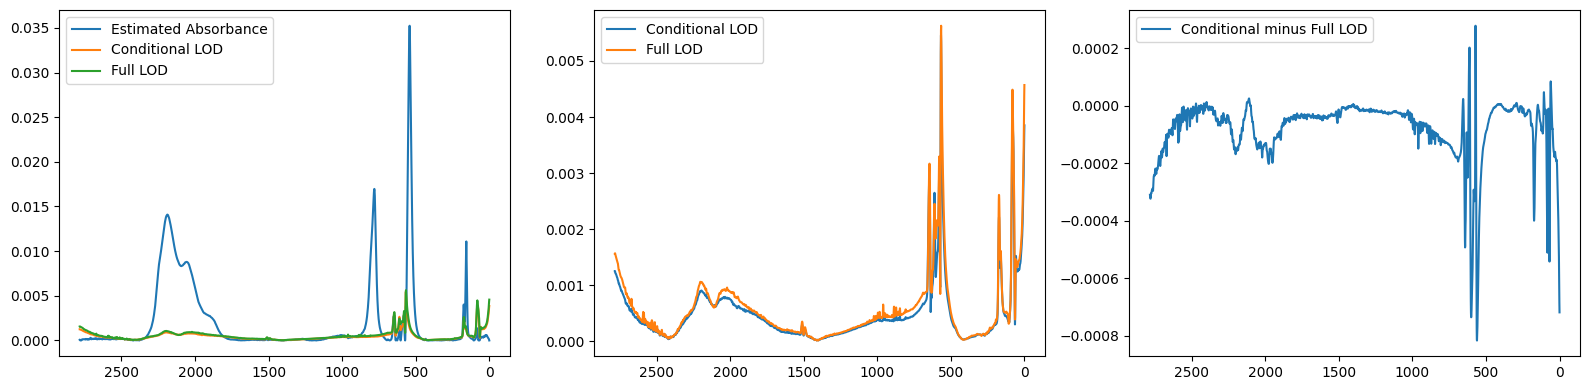

In [72]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))

axes[0].plot(y - z, label="Estimated Absorbance")
axes[0].plot(xi * stdev, label="Conditional LOD")
axes[0].plot(f_xi * f_stdev, label="Full LOD")

axes[1].plot(xi * stdev, label="Conditional LOD")
axes[1].plot(f_xi * f_stdev, label="Full LOD")

axes[2].plot(xi * stdev - f_xi * f_stdev, label = "Conditional minus Full LOD")

for ax in axes:
    ax.legend()
    ax.invert_xaxis()

plt.tight_layout()
plt.show()

The conditional bootstrap required 57.2s compared to the 16m 26.4s needed for the full bootstrap...the differences in the LODs seem fairly minimal.

### LODs for the second randomly selected correction.

In [73]:
#Conditional bootstrap 
dct = corrections_dict[selected[1]]
y = Y.loc[dct["sample_id"]].values
boot_x, boot_z = pca_bootstrap(y, Z, dct["tau"], dct["sigma"], dct["c"], B=100, loss="PB", verbose=False)
z = y - dct["absorbance"]
xi, stdev = compute_lod(boot_z, z, alpha=0.01)

In [74]:
#Full bootstrap
mit = 10000
f_boot_z = []

for _ in tqdm(range(100)):
    Zb = bootstrap_sample(Z)
    mub, _, _, Wb = pca(Zb)
    args = (y, mub, Wb, None, None, "PB", mit, dct["sample_id"])
    res = vibes_help_fun(args)
    f_boot_z.append(y-res["absorbance"])

f_xi, f_stdev = compute_lod(f_boot_z, z, alpha=0.01)

100%|██████████| 100/100 [09:53<00:00,  5.94s/it]


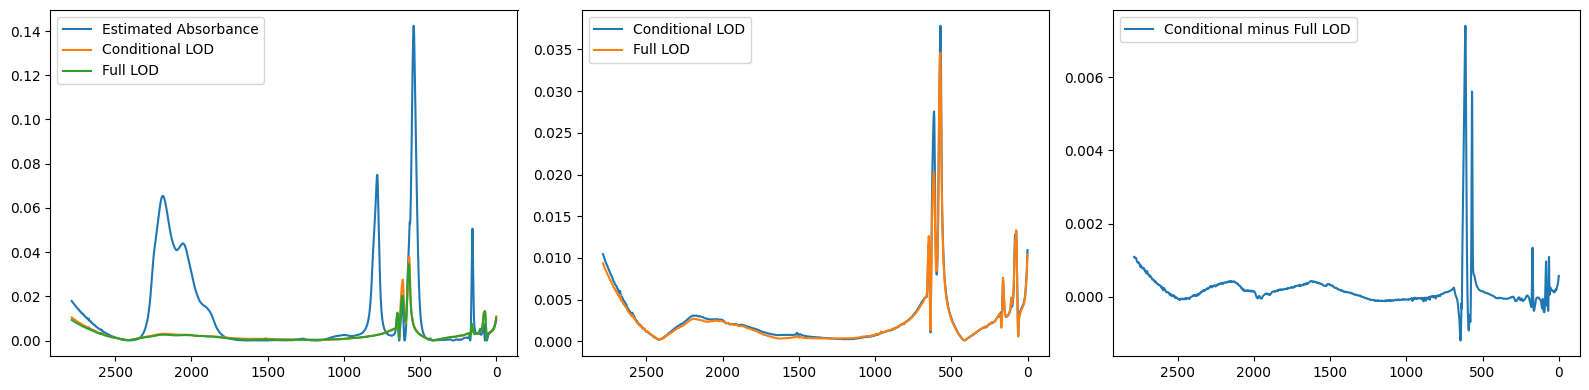

In [75]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))

axes[0].plot(y - z, label="Estimated Absorbance")
axes[0].plot(xi * stdev, label="Conditional LOD")
axes[0].plot(f_xi * f_stdev, label="Full LOD")

axes[1].plot(xi * stdev, label="Conditional LOD")
axes[1].plot(f_xi * f_stdev, label="Full LOD")

axes[2].plot(xi * stdev - f_xi * f_stdev, label = "Conditional minus Full LOD")

for ax in axes:
    ax.legend()
    ax.invert_xaxis()

plt.tight_layout()
plt.show()

The conditional bootstrap required 36.6s vs 9m 53.8s needed for the full bootstrap...the differences in the LODs seem fairly minimal.

### LODs for the third randomly selected correction.

In [76]:
#Conditional bootstrap 
dct = corrections_dict[selected[2]]
y = Y.loc[dct["sample_id"]].values
boot_x, boot_z = pca_bootstrap(y, Z, dct["tau"], dct["sigma"], dct["c"], B=100, loss="PB", verbose=False)
z = y - dct["absorbance"]
xi, stdev = compute_lod(boot_z, z, alpha=0.01)

In [77]:
#Full bootstrap
mit = 10000
f_boot_z = []

for _ in tqdm(range(100)):
    Zb = bootstrap_sample(Z)
    mub, _, _, Wb = pca(Zb)
    args = (y, mub, Wb, None, None, "PB", mit, dct["sample_id"])
    res = vibes_help_fun(args)
    f_boot_z.append(y-res["absorbance"])

f_xi, f_stdev = compute_lod(f_boot_z, z, alpha=0.01)

100%|██████████| 100/100 [15:54<00:00,  9.54s/it]


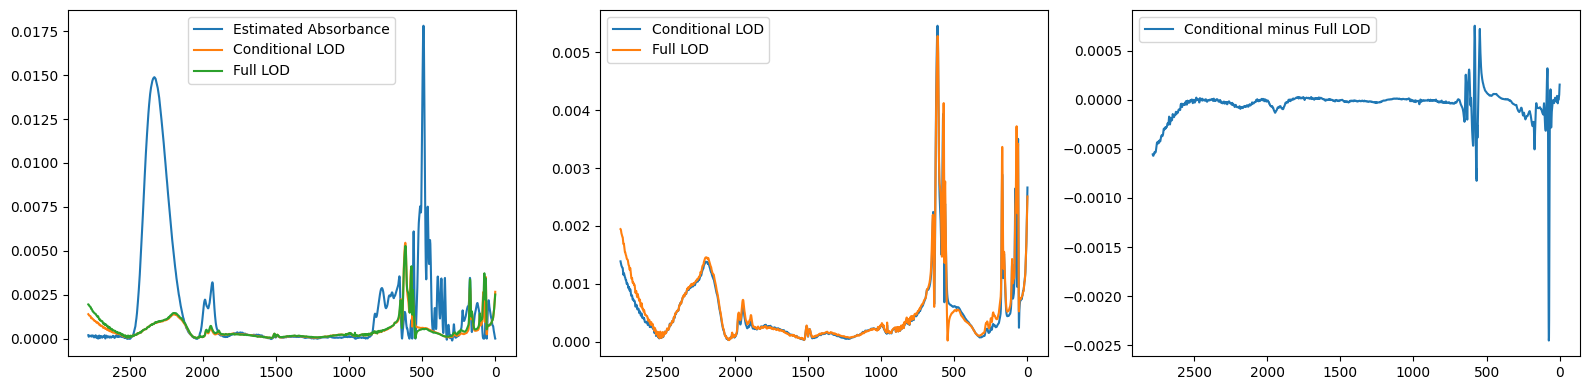

In [78]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))

axes[0].plot(y - z, label="Estimated Absorbance")
axes[0].plot(xi * stdev, label="Conditional LOD")
axes[0].plot(f_xi * f_stdev, label="Full LOD")

axes[1].plot(xi * stdev, label="Conditional LOD")
axes[1].plot(f_xi * f_stdev, label="Full LOD")

axes[2].plot(xi * stdev - f_xi * f_stdev, label = "Conditional minus Full LOD")

for ax in axes:
    ax.legend()
    ax.invert_xaxis()

plt.tight_layout()
plt.show()

The conditional bootstrap required 53.7s vs 15m 54.3s needed for the full bootstrap...the differences in the LODs seem fairly minimal.